In [1]:
# %% Import necessary packages
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

# Read the data from the CSV file

In [2]:
data = pd.read_csv('cleaned_data.csv')

# PCA process

## Data pre-processing
- `y` contains the label `Column Name`
- `X_col` contains all 291 wavelength intensity readings
- `X_scaled` is the standardized version of `X_col` (mean = 0, std = 1)

In [5]:
# Extract all reads from V1 to V291

data['Operator'] = data['Operator'].map({'Dauda': 0, 'Aidan': 1, 'JD': 2, 'Muizat': 3})
data['Batch'] = data['Batch'].map({'B': 0, 'D': 1, 'E' : 2})

X_col = data.drop(columns=["Operator", "Batch", "Column Name"])

# Get the label columns (non-spectral features)
y = data['Column Name']

# Before performing PCA, standardize the data (mean = 0, std = 1)
X_scaled = StandardScaler().fit_transform(X_col)

In [6]:
X_scaled

array([[ 0.29592679,  0.29934702,  0.26913721, ..., -0.57388005,
        -0.48029697, -1.03749473],
       [ 0.14849736,  0.33248133,  0.30913411, ..., -1.36349157,
        -1.06646511, -1.00497924],
       [ 0.21165264,  0.29759661,  0.4014116 , ..., -0.70070128,
        -1.27103975, -2.1423921 ],
       ...,
       [-0.16644145, -0.25457348, -0.20362289, ...,  0.4506373 ,
         0.82124452,  0.56104757],
       [-0.1442573 , -0.22018702, -0.26559567, ...,  0.37828735,
         0.75704375,  0.68977517],
       [-0.1933994 , -0.24002932, -0.27678774, ...,  0.42234981,
         0.69318955,  1.13225909]])

## Perform PCA

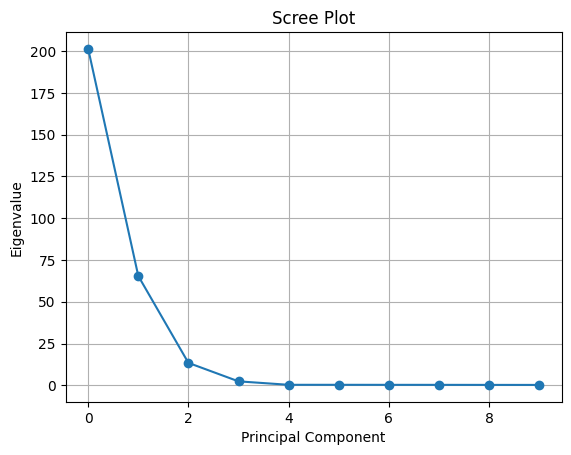

[0.69  0.224 0.046 0.008 0.001 0.001 0.001 0.001 0.001 0.001]


In [7]:
# Initialize PCA with 10 components
pca_model = PCA(n_components=10)

# Fit PCA on the standardized data and transform
X_pca = pca_model.fit_transform(X_scaled)

# Plot the eigenvalues (scree plot)
plt.plot(pca_model.explained_variance_, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

# Print the explained variance ratio of each component
print(np.round(pca_model.explained_variance_ratio_, 3))

In [8]:
print(np.cumsum(pca_model.explained_variance_ratio_))

[0.68979259 0.913926   0.95990846 0.96799237 0.96899027 0.9699703
 0.97088698 0.97177379 0.97257938 0.97333863]


In [9]:
y

0           Blank 1
1           Blank 2
2           Blank 3
3           Blank 4
4           Blank 5
           ...     
330    800pM PFOA 3
331    800pM PFOA 4
332    800pM PFOA 5
333    800pM PFOA 6
334    800pM PFOA 7
Name: Column Name, Length: 335, dtype: object

## Store PCA results in a DataFrame for further analysis


In [10]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame(
    X_pca, 
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

# Combine PCA results with labels
data_PCA = pd.concat([y, pca_df], axis=1)

# Clean up column names: remove numbers after 'Run' and 'CQD'
data_PCA["Column Name"] = data_PCA["Column Name"].str.replace(r"Run\d+", "Run", regex=True)
data_PCA["Column Name"] = data_PCA["Column Name"].str.replace(r"CQD\d+", "CQD", regex=True)

In [11]:
data

,Operator,Batch,Column Name,0,1,2,3,4,5,6,...,281,282,283,284,285,286,287,288,289,290
0,0,0,Blank 1,4.034531,4.074168,4.146334,4.776366,5.166968,5.380499,5.783000,...,2.337577,2.020427,1.975400,1.941748,1.633529,1.988009,1.735568,1.785770,1.741221,1.557681
1,0,0,Blank 2,3.721135,4.139870,4.224371,4.480368,4.970104,5.373269,5.696165,...,2.100548,1.887893,2.019797,1.933458,1.834948,1.688483,1.707889,1.607058,1.610973,1.564751
2,0,0,Blank 3,3.855386,4.070697,4.404411,4.415771,5.035495,5.213314,5.727901,...,2.106403,1.978239,2.042932,1.974319,1.896538,1.892534,1.729521,1.757066,1.565516,1.317423
3,0,0,Blank 4,3.942278,3.979981,3.998706,4.489305,4.952526,5.269382,5.740615,...,2.118773,1.842209,1.912104,2.033359,1.760132,1.929425,1.586962,1.660446,1.618268,1.553990
4,0,0,Blank 5,3.881226,3.961999,4.318709,4.769429,5.028099,5.504888,5.690028,...,2.223238,2.114036,2.101678,1.993529,2.018873,1.755243,1.678757,1.772566,1.536214,1.497676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,3,2,800pM PFOA 3,3.384069,3.198863,3.338003,3.289173,3.294161,3.473016,3.671609,...,2.647264,2.584493,2.458149,2.364505,2.518892,2.278465,2.297079,2.039344,1.957581,2.052233
331,3,2,800pM PFOA 4,3.076697,3.070328,3.007341,3.210100,3.168432,3.441873,3.581242,...,2.829715,2.395520,2.432979,2.338390,2.404724,2.183806,2.105166,2.153930,1.954623,2.038674
332,3,2,800pM PFOA 5,3.051660,2.975800,3.223946,2.917846,3.356260,3.496237,3.350312,...,2.517561,2.622158,2.533744,2.506187,2.244433,2.075557,1.965316,2.017647,2.030426,1.905280
333,3,2,800pM PFOA 6,3.098818,3.043985,3.103033,3.176085,3.335508,3.242160,3.417248,...,2.663279,2.466692,2.615679,2.318618,2.182668,2.322651,2.268402,2.001272,2.016160,1.933272


# Further analyze the PCA outcome
## Visualize the PC1 vs PC2 plot by concentration and Run vs CQD

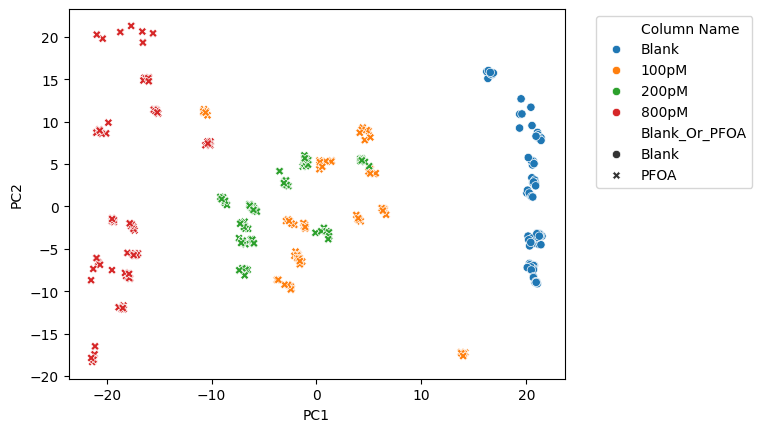

In [12]:
def PCA_no_legend(subset):
    concentration = subset["Column Name"].str.split(" ").str[0] # concentration
    subset["Concentration"] = concentration

    subset["Blank_Or_PFOA"] = np.where(subset["Concentration"].str.contains("Blank"), "Blank", "PFOA")

    pca_df = subset
    pca_df["PC1"] = X_pca[:, 0]
    pca_df["PC2"] = X_pca[:, 1]
    
    sns.scatterplot(data = pca_df, x = "PC1", y = "PC2", hue = concentration, style=subset["Blank_Or_PFOA"], legend = True).legend(bbox_to_anchor=(1.05, 1), loc='upper left') # removed legend

PCA_no_legend(data_PCA)

## Further analyze the eigenvectors of PC1 and PC2
Notice that  

$$
PC_i = \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_{291} X_{291},
$$  

for all $i = 1, 2, \dots, 10$.

Clearly distinguishes 100 pM, 200 pM, 800 pM based on PC1. 

In [13]:
eigenvectors = pca_model.components_

In [14]:
eigenvectors

array([[ 0.01984317,  0.02118349,  0.02164647, ..., -0.05228434,
        -0.05003052, -0.05061772],
       [ 0.06270087,  0.0668152 ,  0.06960162, ...,  0.05037564,
         0.0573564 ,  0.05533166],
       [ 0.16211145,  0.16448197,  0.16653266, ...,  0.04954868,
         0.04945936,  0.05013357],
       ...,
       [ 0.01772224,  0.01923319,  0.04041882, ..., -0.1760621 ,
         0.42432054, -0.28671199],
       [ 0.01788635,  0.00164972,  0.00196904, ..., -0.1089842 ,
        -0.22286265,  0.21868481],
       [-0.01581761, -0.01408541, -0.01408682, ...,  0.0727983 ,
        -0.3399408 ,  0.22091195]])

## Plot eigenvectors (PC1 and PC2 loadings)

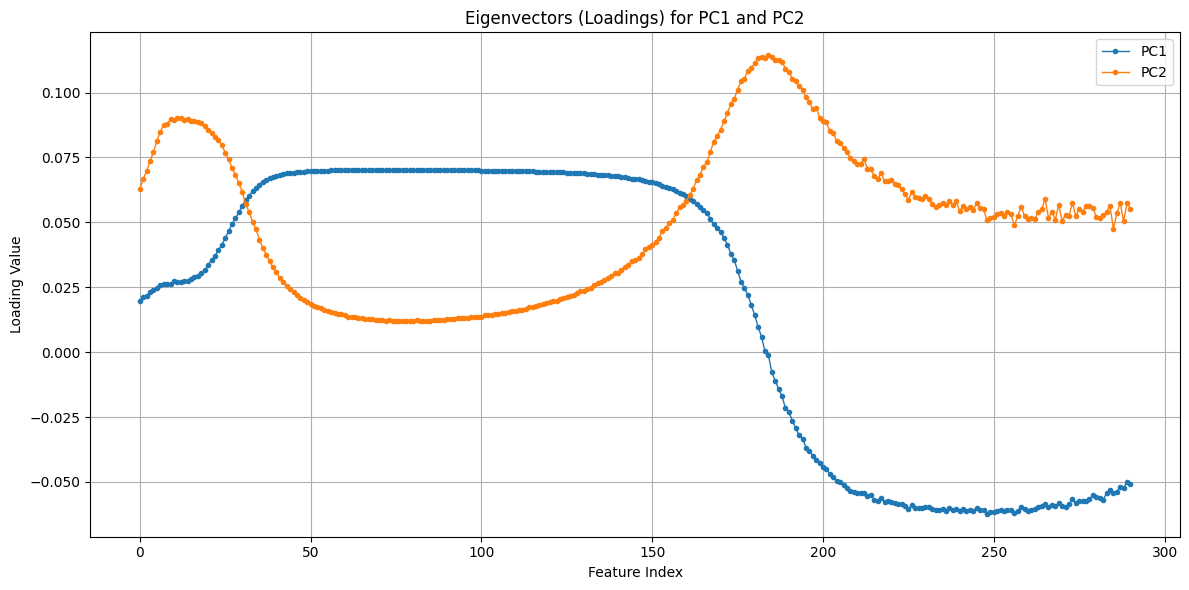

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(eigenvectors[0], label="PC1", marker='o', markersize=3, linewidth=1) # phi_1
plt.plot(eigenvectors[1], label="PC2", marker='o', markersize=3, linewidth=1) # phi_2

plt.title("Eigenvectors (Loadings) for PC1 and PC2")
plt.xlabel("Feature Index")
plt.ylabel("Loading Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Dots: Beta values


Feature index: subscript (1 to 291)

In [16]:
np.percentile(eigenvectors[0], q = 80) # top 20% above this value

0.06978038366285758

In [17]:
# Create DataFrame
df = pd.DataFrame({
    'eigenvalue': eigenvectors[0],
    'flag': 0
})

df.loc[df['eigenvalue'] > np.percentile(eigenvectors[0], q = 80), 'flag'] = 1

print(df['flag'].sum())


58


In [18]:
df[df['flag'] == 1]

,eigenvalue,flag
51,0.069793,1
52,0.069813,1
53,0.069873,1
54,0.069912,1
55,0.069950,1
56,0.069983,1
57,0.070007,1
58,0.070034,1
59,0.070049,1
60,0.070066,1


In [19]:
arr = df[df['flag'] == 0].index
str_arr = np.char.mod('%d', arr)
str_arr

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34',
       '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45',
       '46', '47', '48', '49', '50', '109', '110', '111', '112', '113',
       '114', '115', '116', '117', '118', '119', '120', '121', '122',
       '123', '124', '125', '126', '127', '128', '129', '130', '131',
       '132', '133', '134', '135', '136', '137', '138', '139', '140',
       '141', '142', '143', '144', '145', '146', '147', '148', '149',
       '150', '151', '152', '153', '154', '155', '156', '157', '158',
       '159', '160', '161', '162', '163', '164', '165', '166', '167',
       '168', '169', '170', '171', '172', '173', '174', '175', '176',
       '177', '178', '179', '180', '181', '182', '183', '184', '185',
       '186', '187', '188', '189', '190', '191', '192', '193', '194',
    

In [20]:
data_new = data.drop(columns=str_arr)
data_new

,Operator,Batch,Column Name,51,52,53,54,55,56,57,...,99,100,101,102,103,104,105,106,107,108
0,0,0,Blank 1,416.520355,442.131714,479.110504,504.859100,539.688293,568.197571,595.752991,...,857.831055,842.562012,833.100403,820.363464,804.965698,789.289551,775.988709,758.133911,750.864563,727.928162
1,0,0,Blank 2,418.367371,444.996521,478.202454,505.353760,539.779236,567.350586,592.299927,...,854.565308,844.001892,827.954529,818.192993,805.716919,789.288574,773.373596,761.352295,746.652649,729.515686
2,0,0,Blank 3,417.324158,443.255249,475.802124,508.928833,539.341370,566.865540,594.752502,...,856.790466,842.127930,829.985474,821.927612,802.288574,790.686768,774.882324,764.145813,747.730896,732.237366
3,0,0,Blank 4,417.079651,443.219727,476.247894,504.996246,538.021912,566.396912,594.890625,...,855.847656,845.402161,833.310669,817.590088,802.991028,787.713379,778.247803,764.680298,749.555725,729.999268
4,0,0,Blank 5,414.979401,442.749390,474.092560,501.491303,540.710449,565.331238,594.148254,...,853.477783,847.711792,830.612549,822.227600,803.359680,789.721497,774.601990,763.026367,747.329529,729.820068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,3,2,800pM PFOA 3,146.827332,156.820404,171.167068,180.851242,195.635498,207.948669,218.931992,...,459.973480,455.043152,451.520233,452.034637,446.550049,442.987701,438.769684,433.455109,427.802795,421.015991
331,3,2,800pM PFOA 4,147.796493,159.475967,172.548416,184.377853,198.046158,209.140869,220.609100,...,460.117462,459.222870,453.591156,452.035889,448.823639,446.664337,442.001312,439.149597,435.397369,428.537689
332,3,2,800pM PFOA 5,149.859070,158.571030,171.576828,184.458313,196.295898,208.185852,221.093567,...,458.368042,460.109192,456.065918,452.085907,448.064056,444.574280,440.494324,436.997650,431.347107,425.471497
333,3,2,800pM PFOA 6,147.372345,157.338760,172.067673,185.279068,197.152176,209.151825,221.874908,...,459.974365,459.188751,456.432373,453.237732,446.052643,442.204224,440.813934,434.520111,432.110138,426.820129


In [21]:
data_2 = pd.read_csv("data_2_cleaned.csv")
data_2

,0,1,2,3,4,5,6,7,8,9,...,282,283,284,285,286,287,288,289,290,Concentration
0,6.04185,5.95194,6.18743,5.82100,6.00895,5.87196,6.19672,6.09720,6.71927,6.62551,...,2.25833,2.29966,2.07811,2.31174,2.07265,1.94410,1.71991,1.72774,1.56711,NaN
1,4.99333,5.12343,5.05339,4.71818,5.46285,5.13554,5.48979,5.74889,6.02093,6.14581,...,2.14040,1.87234,2.09058,1.88342,1.93860,1.77154,1.65568,1.68892,1.72598,50.0
2,4.95845,5.02208,5.07989,5.57982,5.33959,5.76665,6.28235,6.38248,6.51291,7.23259,...,2.51949,2.54532,2.16631,2.18311,2.08966,2.02792,1.95110,2.06906,1.86259,100.0
3,4.50194,4.41498,4.58356,4.67038,5.10968,5.24423,5.45987,5.99981,6.15437,6.43335,...,2.63635,2.72853,2.53222,2.43086,2.48498,2.16778,2.15823,2.12824,1.85902,150.0
4,3.50919,3.79848,3.80101,4.16474,4.42276,4.86116,5.04535,5.34625,5.98181,6.40705,...,2.63487,2.41683,2.61242,2.44488,2.62734,2.24121,2.23707,2.22132,2.11338,200.0
5,3.07444,3.38234,3.64804,3.73480,4.20660,4.25325,4.71530,5.18492,5.12141,5.77231,...,2.63318,2.59302,2.71596,2.29809,2.23419,2.32834,1.96184,1.87185,2.02408,300.0
6,3.96037,3.82993,3.98497,4.44734,4.43105,4.64183,4.98284,5.43445,6.07750,6.51624,...,3.13964,3.15875,2.91927,2.58141,2.77941,2.74131,2.79859,2.47735,2.53765,500.0
7,3.41281,3.96568,3.59034,4.16899,4.43039,4.97199,5.05043,5.37237,5.58993,6.03100,...,2.87281,3.27061,2.93054,2.89585,2.81296,2.49568,2.59637,2.70303,2.26869,700.0
8,3.74862,3.98666,4.08170,4.42372,4.67784,4.93445,5.12316,5.53700,5.68282,6.36100,...,2.84324,2.93185,2.94157,2.70221,2.64562,2.61446,2.30618,2.40834,2.18866,800.0
9,3.87695,4.02451,4.25305,4.49506,5.05856,5.21443,5.41809,5.58498,6.39526,6.55687,...,3.30965,3.11802,3.10684,2.52888,2.76971,2.59906,2.59079,2.49607,2.31585,600.0


In [22]:
data_2_new = data_2.drop(columns=str_arr)
data_2_new

,51,52,53,54,55,56,57,58,59,60,...,100,101,102,103,104,105,106,107,108,Concentration
0,433.88550,461.86624,495.85010,528.86346,567.75110,593.40845,623.31152,650.22937,684.53033,711.30518,...,865.69232,860.00568,841.61957,823.86957,814.00769,801.36926,783.87622,770.80261,756.17828,NaN
1,377.86630,404.18655,434.23117,461.54211,491.81226,518.29846,545.07660,564.58105,596.92993,621.93323,...,781.68420,775.21161,762.48895,746.39764,738.16046,722.66211,713.68549,701.84308,683.02277,50.0
2,337.00070,354.65021,385.90231,409.28958,436.77271,457.76566,481.47552,504.63306,528.85455,549.34845,...,734.69391,720.82776,713.61359,699.70099,687.66357,678.87488,669.49640,657.62500,649.58087,100.0
3,325.73001,345.50333,376.84015,400.34079,426.14252,448.30783,471.86569,492.36490,518.21167,536.07690,...,734.45593,722.48529,714.55304,705.86658,690.88568,683.88886,669.63709,659.37823,648.83826,150.0
4,294.39151,316.65884,340.78214,363.03928,390.59647,409.53989,429.99521,447.27200,474.52112,492.99371,...,699.69696,693.24799,685.89545,673.89154,668.66394,658.83923,650.10242,638.85077,624.16241,200.0
5,291.09637,307.31714,334.98679,355.30579,379.17590,397.35742,420.27594,438.17264,461.91086,480.60840,...,679.41815,670.60687,664.38141,651.66150,640.24774,634.16919,628.32263,614.90283,603.15857,300.0
6,247.67888,262.72131,285.18961,303.60168,321.69055,339.85767,358.15503,377.40097,398.06381,417.17084,...,643.34930,641.42438,637.86725,625.91241,618.99384,615.80170,605.11853,599.69806,588.70801,500.0
7,193.88077,204.93251,221.05278,236.31038,253.12686,265.27005,281.11475,293.87405,310.46207,324.76395,...,551.87598,549.00806,548.70856,543.18402,536.42615,529.25043,522.60645,519.88348,514.79657,700.0
8,177.31532,190.10226,205.65279,219.71530,231.12459,246.73842,261.13730,271.43091,287.56647,297.19131,...,520.06732,513.69440,512.22144,505.44357,504.47864,496.78250,493.11935,491.75833,485.74527,800.0
9,227.38655,239.13275,259.33664,278.38223,296.06082,310.73239,326.07538,342.01498,359.20703,378.29279,...,601.96539,600.42706,595.16870,590.04962,583.28632,578.48602,570.84332,562.23407,557.48889,600.0


In [23]:
data_2_new.to_csv("data_2_80th_percentile.csv", index = False)

In [24]:
data_new.to_csv("80th_percentile.csv", index=False)